# 01 — The sprinkler network in pgmpy
**Worked example • IMT Mines Alès • Andon Tchechmedjiev**

This is a complete example to read, run and adapt—not another assessed assignment.
Spend about **20 minutes on sections 1–7**. Use section 8 as a recipe during the
occupancy practical; section 9 gives additional checks.

We keep exactly the illustrative network and numerical CPDs used in the lecture.
These are teaching assumptions, not measured weather or road-safety probabilities.

| Lecture symbol | Code name | State 1 means |
|---|---|---|
| A | `Winter` | It is winter |
| B | `Sprinkler` | Sprinkler is on |
| C | `Rain` | It is raining |
| D | `WetGrass` | Grass is wet |
| E | `Slippery` | Road is slippery |

**Every variable uses the explicit state order `[0, 1]`: false, then true.**
Some lecture tables list state 1 before state 0. Transpose/reorder by meaning,
not by copying positions.

Target API: pgmpy 1.1.2. Use the course environment installed before class.
The notebook has no data download or dependency-installation cell and needs no
external dataset. Its code is complete, but execution outputs are intentionally
empty in this authored version; mathematical reference values below are not
claimed software-run outputs.

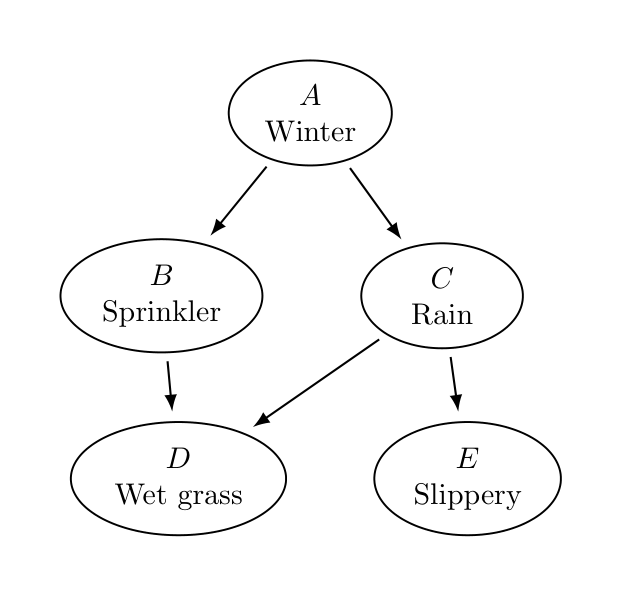

## 1. Import the four objects we need
`DiscreteBayesianNetwork` stores the DAG and CPDs, `TabularCPD` represents a table,
`VariableElimination` answers posterior queries, and `BayesianEstimator` learns CPDs
when we have complete training records. Import all dependencies in this notebook.

In [1]:
from importlib.metadata import version
from itertools import product
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination
    from pgmpy.estimators import BayesianEstimator
except ImportError as exc:
    raise ImportError(
        "Open the course Python environment. Before class, install requirements.txt; "
        "the example targets pgmpy 1.1.2. See QUICKSTART.md."
    ) from exc

print("pgmpy:", version("pgmpy"))
print("numpy:", version("numpy"), "pandas:", version("pandas"))

ImportError: Open the course Python environment. Before class, install requirements.txt; the example targets pgmpy 1.1.2. See QUICKSTART.md.

## 2. Declare variables, states and edges
A graph alone is **not yet a complete probabilistic model**. We add its CPDs next.
Do not reverse arrows when switching from a predictive to a diagnostic question.

In [ ]:
VARIABLES = ["Winter", "Sprinkler", "Rain", "WetGrass", "Slippery"]
STATE_NAMES = {variable: [0, 1] for variable in VARIABLES}
EDGES = [
    ("Winter", "Sprinkler"),
    ("Winter", "Rain"),
    ("Sprinkler", "WetGrass"),
    ("Rain", "WetGrass"),
    ("Rain", "Slippery"),
]

model = DiscreteBayesianNetwork(EDGES)
model.add_nodes_from(VARIABLES)  # Important in general when a variable is isolated.
print("Parents of WetGrass:", sorted(model.get_parents("WetGrass")))

## 3. Attach the conditional probability tables
In `TabularCPD`, `variable` is the child; **`evidence` names its parents**. This use
of the word evidence describes the CPD structure. It does not say that these parents
have been observed in a particular query.

Rows follow the child's `state_names`. Columns enumerate parent configurations;
the **last listed parent changes fastest**.

For `evidence=["Sprinkler", "Rain"]` with states `[0,1]`, the four columns are:

| Column | Sprinkler | Rain | P(WetGrass=1 | parents) |
|---|---:|---:|---:|
| 0 | 0 | 0 | 0.00 |
| 1 | 0 | 1 | 0.80 |
| 2 | 1 | 0 | 0.90 |
| 3 | 1 | 1 | 0.95 |

Each column must sum to one across the two child states.

In [ ]:
cpd_winter = TabularCPD(
    variable="Winter", variable_card=2,
    values=[[0.40], [0.60]],
    state_names={"Winter": [0, 1]},
)
cpd_sprinkler = TabularCPD(
    variable="Sprinkler", variable_card=2,
    values=[[0.25, 0.80], [0.75, 0.20]],
    evidence=["Winter"], evidence_card=[2],
    state_names={"Sprinkler": [0, 1], "Winter": [0, 1]},
)
cpd_rain = TabularCPD(
    variable="Rain", variable_card=2,
    values=[[0.90, 0.20], [0.10, 0.80]],
    evidence=["Winter"], evidence_card=[2],
    state_names={"Rain": [0, 1], "Winter": [0, 1]},
)
cpd_wet_grass = TabularCPD(
    variable="WetGrass", variable_card=2,
    values=[[1.00, 0.20, 0.10, 0.05], [0.00, 0.80, 0.90, 0.95]],
    evidence=["Sprinkler", "Rain"], evidence_card=[2, 2],
    state_names={"WetGrass": [0, 1], "Sprinkler": [0, 1], "Rain": [0, 1]},
)
cpd_slippery = TabularCPD(
    variable="Slippery", variable_card=2,
    values=[[1.00, 0.30], [0.00, 0.70]],
    evidence=["Rain"], evidence_card=[2],
    state_names={"Slippery": [0, 1], "Rain": [0, 1]},
)
model.add_cpds(cpd_winter, cpd_sprinkler, cpd_rain, cpd_wet_grass, cpd_slippery)
print(model.get_cpds("WetGrass"))

## 4. Validate before querying
`check_model()` checks the graph/CPD consistency. Also check individual entries
by their **named states**: a perfectly normalised table can still contain values
assigned to the wrong parent configuration.

In [ ]:
assert model.check_model()
for cpd in model.get_cpds():
    values = np.asarray(cpd.get_values(), dtype=float)
    assert np.isfinite(values).all() and (values >= 0).all()
    np.testing.assert_allclose(values.sum(axis=0), 1.0, atol=1e-12, rtol=0)

assert np.isclose(cpd_sprinkler.get_value(Sprinkler=1, Winter=1), 0.20)
assert np.isclose(cpd_wet_grass.get_value(WetGrass=1, Sprinkler=0, Rain=1), 0.80)
assert np.isclose(cpd_slippery.get_value(Slippery=1, Rain=0), 0.00)
print("CPDs are consistent and the selected named entries are correct.")

## 5. Ask a posterior question
Compute $P(\mathrm{Slippery}=1\mid\mathrm{Winter}=1,\mathrm{Sprinkler}=1)$.
Here `evidence` is a **dictionary of observed states**, not a parent list.
Do not put the query variable into that dictionary.

The result is a probability distribution over the query. Access its value by
state name using `get_value`, rather than assuming a particular array position.

In [1]:
inference = VariableElimination(model)
road = inference.query(
    variables=["Slippery"],
    evidence={"Winter": 1, "Sprinkler": 1},
    elimination_order="MinFill", show_progress=False,
)
print(road)
p_road = float(road.get_value(Slippery=1))
manual = 0.80 * 0.70 + 0.20 * 0.00
np.testing.assert_allclose(p_road, manual, atol=1e-12, rtol=0)
print("P(Slippery=1 | Winter=1, Sprinkler=1) =", p_road)

NameError: name 'VariableElimination' is not defined

**Check your interpretation.** The reference answer is **0.56**. Why does the
sprinkler add no information about slipperiness once winter is known? The wet-grass
node is unobserved, so the collider path remains blocked. Check the reduced query.

In [ ]:
road_without_sprinkler = inference.query(
    variables=["Slippery"], evidence={"Winter": 1},
    elimination_order="MinFill", show_progress=False,
)
np.testing.assert_allclose(
    road_without_sprinkler.get_value(Slippery=1), p_road, atol=1e-12, rtol=0
)

## 6. Change the evidence, not the model
Given winter and wet grass, rain is one possible explanation. Learning that the
sprinkler was on changes the rain posterior. Predict its direction first.

The small function below is a pattern to adapt: validate variable/state names,
query, and read the state-1 probability. Evidence must have positive probability
under the model; a structural-zero contradiction does not define a posterior.

In [ ]:
def probability_of_one(query: str, evidence: dict[str, int] | None = None) -> float:
    evidence = {} if evidence is None else dict(evidence)
    if query not in STATE_NAMES or query in evidence:
        raise ValueError("Use a known query variable that is not also observed.")
    for name, value in evidence.items():
        if name not in STATE_NAMES or value not in STATE_NAMES[name]:
            raise ValueError(f"Unknown variable or state: {name}={value}")
    result = inference.query(
        variables=[query], evidence=evidence,
        elimination_order="MinFill", show_progress=False,
    )
    p = float(result.get_value(**{query: 1}))
    if not np.isfinite(p):
        raise ValueError("Nonfinite posterior: check for impossible evidence.")
    return p

rain_before = probability_of_one("Rain", {"Winter": 1, "WetGrass": 1})
rain_after = probability_of_one("Rain", {"Winter": 1, "WetGrass": 1, "Sprinkler": 1})
np.testing.assert_allclose([rain_before, rain_after], [166/175, 38/47], atol=1e-12, rtol=0)
display(pd.DataFrame({
    "evidence": ["winter, wet grass", "winter, wet grass, sprinkler on"],
    "P(Rain=1 | evidence)": [rain_before, rain_after],
}))

The mathematical reference values are about **0.949** and **0.809**. This is
explaining away for these CPDs, not a theorem that all collider parameterisations
produce the same direction of change.

## 7. Unavailable is not the same as false
An unavailable sprinkler observation is **omitted**. A confirmed inactive sprinkler
is `Sprinkler=0`. Never pass `None` or zero as a substitute for an unknown state.

In [ ]:
base_evidence = {"Winter": 1, "WetGrass": 1}
p_missing = probability_of_one("Rain", base_evidence)
p_off = probability_of_one("Rain", {**base_evidence, "Sprinkler": 0})
p_no_evidence = probability_of_one("Rain", {})
np.testing.assert_allclose([p_missing, p_off, p_no_evidence], [166/175, 1.0, 0.52], atol=1e-12, rtol=0)
print({"sprinkler unavailable": p_missing, "sprinkler known off": p_off,
       "no evidence: rain marginal": p_no_evidence})

The certainty when the sprinkler is off comes from the model's structural zero:
wet grass without rain or sprinkling has probability zero. It is not a claim about
all real lawns. With no evidence, a query returns its model marginal; for a **root**
variable such as occupancy in the practical, that marginal is its root CPD/prior.

**Stop the initial walkthrough here.** Begin transposing variables, state names
and edges to the occupancy starter. Return to section 8 when fitting parameters.

## 8. Recipe for learning CPDs from complete records
For occupancy, the CPD values are **learned from the supplied training data**, not
copied from the sprinkler. This example uses a reproducible synthetic sprinkler
sample solely to illustrate the API. It is not the real occupancy dataset.

In [ ]:
# Synthetic complete records sampled in topological order from the teaching CPDs.
rng = np.random.default_rng(42)
n = 2000
winter = (rng.random(n) < 0.60).astype(int)
sprinkler = (rng.random(n) < np.where(winter == 1, 0.20, 0.75)).astype(int)
rain = (rng.random(n) < np.where(winter == 1, 0.80, 0.10)).astype(int)
wet_probabilities = np.array([[0.00, 0.80], [0.90, 0.95]])  # Indexed by sprinkler, rain.
wet = (rng.random(n) < wet_probabilities[sprinkler, rain]).astype(int)
slippery = (rng.random(n) < np.where(rain == 1, 0.70, 0.00)).astype(int)
training_records = pd.DataFrame({"Winter": winter, "Sprinkler": sprinkler,
                                 "Rain": rain, "WetGrass": wet, "Slippery": slippery})
display(training_records.head())

In [ ]:
learned_model = DiscreteBayesianNetwork(EDGES)
learned_model.add_nodes_from(VARIABLES)
estimator = BayesianEstimator(learned_model, training_records, state_names=STATE_NAMES)
learned_cpds = estimator.get_parameters(
    prior_type="dirichlet", pseudo_counts=1, n_jobs=1
)
learned_model.add_cpds(*learned_cpds)
assert learned_model.check_model()
print(learned_model.get_cpds("Sprinkler"))

# One pseudocount per child state and parent configuration: posterior mean.
subset = training_records.loc[training_records["Winter"] == 1, "Sprinkler"]
manual_smoothed = (int((subset == 1).sum()) + 1) / (len(subset) + 2)
software_smoothed = learned_model.get_cpds("Sprinkler").get_value(Sprinkler=1, Winter=1)
np.testing.assert_allclose(software_smoothed, manual_smoothed, atol=1e-12, rtol=0)
print("Manual posterior-mean check:", manual_smoothed)

`pseudo_counts=1` here means **one count in every CPD cell**. It is not a global
BDeu equivalent sample size of one. This returns posterior-mean CPDs, not MAP modes.
The learned model is separate: the original illustrative model remains unchanged.

### Transpose this pattern to your occupancy task

| Keep the method | Change for the occupancy exercise |
|---|---|
| Explicit variable/state names | Use `O,T,L,S,C,M` and the supplied state dictionary |
| DAG construction | Make occupancy `O` the parent of each sensor feature |
| CPD consistency checks | Fit the CPDs from **training records only** using section 8 |
| `VariableElimination.query` | Query `O`, then use `get_value(O=1)` |
| Evidence dictionaries | Include sensor values, never occupancy labels or timestamps |
| Omit unavailable variables | Remove the assigned sensor key; do not refit the model |
| A hand-calculated check | Verify one learned CPD entry and the no-sensor/prior equality |

The occupancy notebook supplies data loading, fixed preprocessing metadata, caching
and scoring. Your work is the model, CPDs, queries and interpretation. The sprinkler
probabilities **must not** be transplanted into the occupancy model.
